In [17]:
import os

os.environ["R_HOME"] = r"C:\Program Files\R\R-4.5.2"
r_bin = r"C:\Program Files\R\R-4.5.2\bin\x64"
os.environ["PATH"] = r_bin + os.pathsep + os.environ["PATH"]

import os
print("R_HOME:", os.environ.get("R_HOME"))
print(os.path.exists(os.environ.get("R_HOME", "")))
print(os.path.exists(os.path.join(os.environ.get("R_HOME", ""), "bin", "x64", "R.dll")))

R_HOME: C:\Program Files\R\R-4.5.2
True
True


In [18]:
from src.gmm import GMM
from src.dg import DataGenerator
from src.metrics import energy_distance, hellinger_gaussian_diag_gmm, hellinger_normal_gmm

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t, gaussian_kde

import torch

from src.gaussian_mixture import GaussianMixtureMAR
from sklearn.mixture import GaussianMixture

# controled missingness functions adapted from R but not exactly the same
# still using ampute from mice in R
from src.mdm import ampute_mar

In [ ]:
# global parameters
N = 2000
d = 10
# new samples
n_samples = 2000

# number of inits for the EM - sklearn and our method
n_inits=20

# selection by aic/bic
k_range = range(1, 51, 5)

crit = 'bic'
ct = 'diag'

In [20]:
k_range

range(1, 51, 5)

# Functions to set the MDM distributions

- input1: the probability of the completely observed
- input2: the probability of the worst missingness, i.e., all missing except the last column

In [21]:
def mdm_dist(d, p_complete, p_all_missing=None):
    n_pats = 2**(d-1) - 1
    if p_all_missing is None:
        pm = np.ones(n_pats)
        pm /= pm.sum()
        pm *= 1 - p_complete
        return np.append(pm, p_complete)

    pm = np.ones(n_pats - 1)
    pm /= pm.sum()
    pm *= 1 - p_complete - p_all_missing
    pm = np.insert(pm, 0, p_all_missing)
    return np.append(pm, p_complete)

# Decrease the probability of fully observed

In [22]:
pc_range = [0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.1]

## Case 1: Gaussian mixture with $k=5$

In [23]:
dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5
mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### KDE

In [24]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### Our method with full data

In [25]:
gmm_full = GaussianMixtureMAR(
    k_range=k_range,
    criterion=crit,
    device='cpu',
    cov_type=ct,
    n_init=n_inits
)
gmm_full.fit(X, M_full)
print('best k =', gmm_full.best_k)
gmm_full_ed = [energy_distance(X, gmm_full.sample(n_samples)[0]) for _ in range(100)]

best k = 36


### Sklearn GM

In [26]:
gmm_sk = GaussianMixture(
    n_components=gmm_full.best_k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### Our method with increasing missingness

In [27]:
eds = []
for p in pc_range:
    pp = mdm_dist(d, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmm = GaussianMixtureMAR(
        k_range=k_range, 
        criterion=crit,
        device='cpu', 
        cov_type=ct, 
        n_init=n_inits
    )
    gmm.fit(X_filled, M)
    #print('best k=', gmm.best_k)

    gmm_ed = [energy_distance(X_filled, gmm.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmm_ed)

In [48]:
gmm.best_k

16

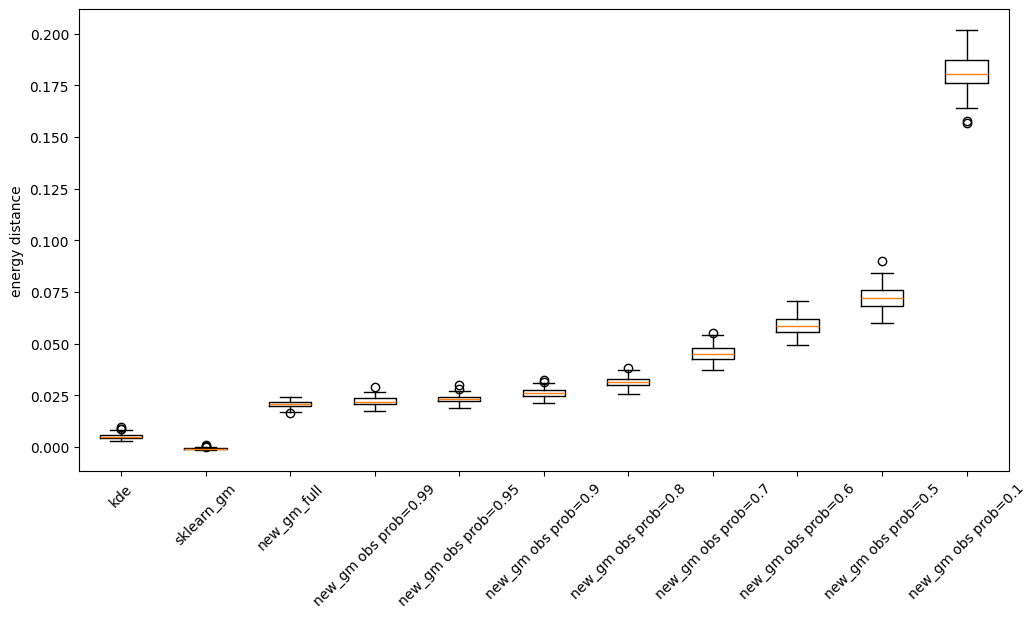

In [28]:
labels = ['new_gm obs prob=' + str(x) for x in pc_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmm_full_ed, *eds])
plt.xticks(list(range(1,len(pc_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()

## Case 2: Normal

$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$

In [29]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### KDE

In [30]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### Our method with full data

In [31]:
gmm_full = GaussianMixtureMAR(
    k_range=k_range, 
    criterion=crit,
    device='cpu', 
    cov_type=ct, 
    n_init=n_inits
)
gmm_full.fit(X, M_full)
print('best k = ', gmm_full.best_k)
gmm_full_ed = [energy_distance(X, gmm_full.sample(n_samples)[0]) for _ in range(100)]

best k =  26


### Sklearn GM

In [32]:
gmm_sk = GaussianMixture(
    n_components=gmm_full.best_k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### Our method with increasing missingness

In [33]:
eds = []
for p in pc_range:
    pp = mdm_dist(d, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmm = GaussianMixtureMAR(
        k_range=k_range, 
        criterion=crit,
        device='cpu', 
        cov_type=ct, 
        n_init=n_inits
    )
    gmm.fit(X_filled, M)
    print('best k =', gmm.best_k)

    gmm_ed = [energy_distance(X_filled, gmm.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmm_ed)

best k = 36
best k = 46
best k = 41
best k = 46
best k = 21
best k = 36
best k = 31
best k = 11


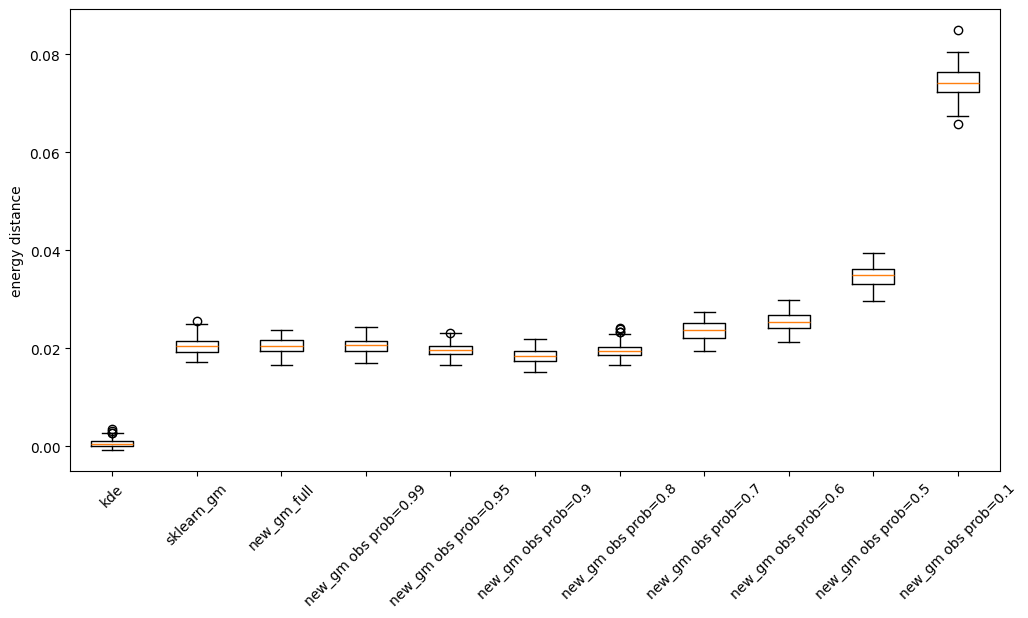

In [34]:
labels = ['new_gm obs prob=' + str(x) for x in pc_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmm_full_ed, *eds])
plt.xticks(list(range(1,len(pc_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()

# Increase the probability of the worst missingness probability

In [35]:
pc = 0.5
pam_range = [0.05, 0.1, 0.2, 0.3, 0.4]
len(pam_range)

5

## Case 1: Gaussian mixture with $k=5$

In [36]:
dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5
mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### KDE

In [37]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### Our method with full data

In [38]:
gmm_full = GaussianMixtureMAR(
    k_range=k_range, 
    criterion=crit,
    device='cpu', 
    cov_type=ct, 
    n_init=n_inits
)
gmm_full.fit(X, M_full)

gmm_full_ed = [energy_distance(X, gmm_full.sample(n_samples)[0]) for _ in range(100)]

### Sklearn GM

In [39]:
gmm_sk = GaussianMixture(
    n_components=gmm_full.best_k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### Our method with increasing missingness

In [40]:
eds = []
for p in pam_range:
    pp = mdm_dist(d, pc, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmm = GaussianMixtureMAR(
        k_range=k_range, 
        criterion=crit,
        device='cpu', 
        cov_type=ct, 
        n_init=n_inits
    )
    gmm.fit(X_filled, M)
    print('best k = ', gmm.best_k)

    gmmt_ed = [energy_distance(X_filled, gmm.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmmt_ed)

best k =  46
best k =  31
best k =  21
best k =  21
best k =  41


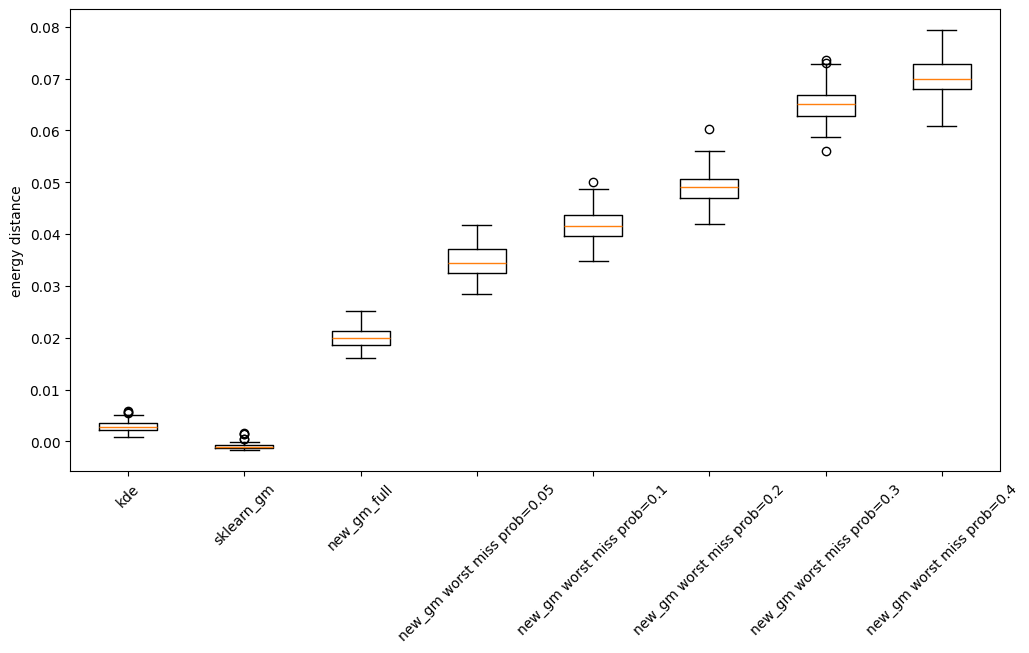

In [41]:
labels = ['new_gm worst miss prob=' + str(x) for x in pam_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmm_full_ed, *eds])
plt.xticks(list(range(1,len(pam_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()

## Case 2: Normal

$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$

In [42]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### KDE

In [43]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### Our method with full data

In [44]:
gmm_full = GaussianMixtureMAR(
    k_range=k_range, 
    criterion=crit,
    device='cpu', 
    cov_type=ct, 
    n_init=n_inits
)
gmm_full.fit(X, M_full)

gmm_full_ed = [energy_distance(X, gmm_full.sample(n_samples)[0]) for _ in range(100)]

### Sklearn GM

In [45]:
gmm_sk = GaussianMixture(
    n_components=gmm_full.best_k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### Our method with increasing missingness

In [46]:
eds = []
for p in pam_range:
    pp = mdm_dist(d, pc, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmm = GaussianMixtureMAR(
        k_range=k_range, 
        criterion=crit,
        device='cpu', 
        cov_type=ct, 
        n_init=n_inits
    )
    gmm.fit(X_filled, M)
    print('best k = ', gmm.best_k)

    gmmt_ed = [energy_distance(X_filled, gmm.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmmt_ed)

best k =  41
best k =  46
best k =  41
best k =  16
best k =  16


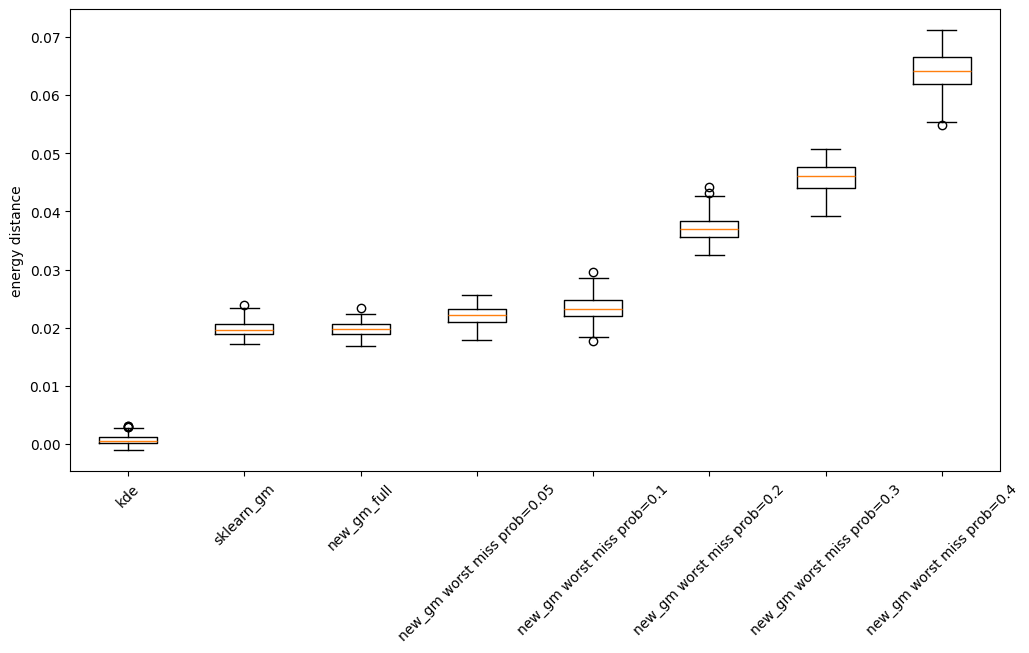

In [47]:
labels = ['new_gm worst miss prob=' + str(x) for x in pam_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmm_full_ed, *eds])
plt.xticks(list(range(1,len(pam_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()